# Stepwise Ionization

In [2]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

## Read LXCat cross-section datasets

In [3]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","TRINITI","SIGLO"]
Nsets = len(datasets)

## Read experimental measurement datasets

In [4]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Preparation of datasets used for Bayesian inference

4.211257479999999
Ton-That, D., & Flannery, M. R. (1977). Cross sections for ionization of metastable rare-gas atoms (Ne*, Ar*, Kr*, Xe*) and of metastable N2*, CO* molecules by electron impact. Physical Review A, 15(2), 517–526. https://doi.org/10.1103/PhysRevA.15.517
5.54764
4.2


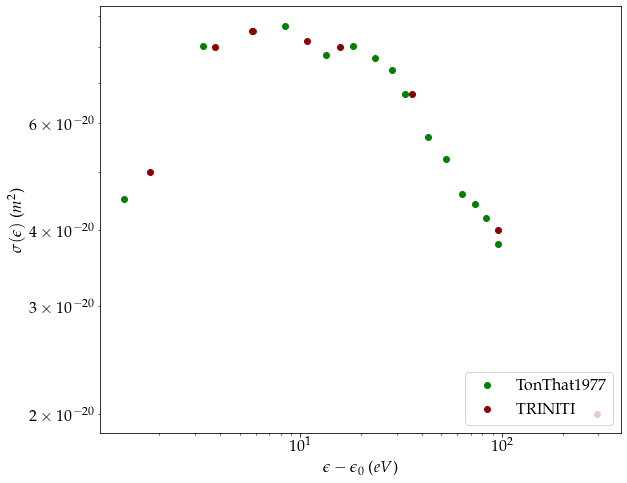

In [4]:
from models import *
dataType = crs.typeDictS2I['Step-wise Ionization, 1+']
deltaE = E_ion[0] - E_ext[0]
threshold = np.floor(10*deltaE)/10.0
print(deltaE)

targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        temp[:,2] = temp[:,1] * 0.18
        print(temp[0,0])
        W += [temp]
        
# Include TRINITI dataset, except the first entry (excitation level).
for c in TRINITI.crs:
    if ((c.colType==3) and (c.deltaE>=threshold) and (c.deltaE<=threshold+0.1)):
        targetrefs += ['TRINITI']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.18
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([-1, 10, 10])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + deltaE
model0 = total_Ion_BED(theta_ref,Etest, deltaE)
mask = model0 > 1.0e-25
# Etest = Etest[mask]
# model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     plt.errorbar(Wk[:,0]-deltaE,Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
    plt.loglog(Wk[:,0]-deltaE,Wk[:,1],'o',color=colors[k+1],label=targetrefs[k])
# plt.loglog(Etest - deltaE,model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon - \epsilon_0$ ($eV$)')
plt.ylabel('$\sigma(\epsilon)$ ($m^2$)')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.tight_layout()
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
fig.savefig('./step-wise.ionization.exp.pdf',dpi=1200)


## Log-scaling of datasets
## Pre-processing of datasets for Gaussian-process kernel

[0.16551444 0.16551444 0.16551444 0.16551444 0.16551444 0.16551444
 0.16551444 0.16551444 0.16551444 0.16551444 0.16551444 0.16551444
 0.16551444 0.16551444 0.16551444] [-44.54598267 -43.96553511 -43.90937267 -43.89058974 -44.0030745
 -43.9689142  -44.01076939 -44.05846564 -44.14956285 -44.31197902
 -44.3967681  -44.52749244 -44.56608912 -44.61717137 -44.71478465]


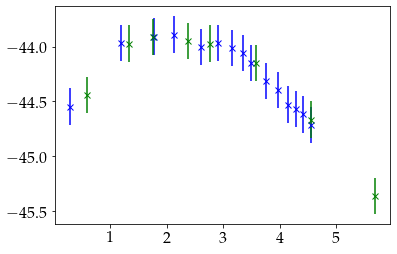

In [105]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - deltaE)
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]
    
print(ed[0], yd[0])

### Finding a good initial guess by least-square optimization

In [6]:
import torch
from models import *

targetW = torch.tensor(W[0])

class total_Ion_BED(torch.nn.Module):
    def __init__(self, theta):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        a, b, c = theta
        self.a = torch.nn.Parameter(torch.tensor(a))
        self.b = torch.nn.Parameter(torch.tensor(b))
        self.c = torch.nn.Parameter(torch.tensor(c))

    def forward(self):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        
        E = torch.clone(targetW[:,0])
    
        t = E / deltaE
        
        return 4. * np.pi * a0 * a0 / t * ( self.a * np.log(t) + self.b * (1. - 1. / t) + self.c * np.log(t) / (t + 1.) )

# [-1.44, 54.97, -69.50, 0.70, 0.43, 0.43, 0.68
theta_ref = [-1., 10., 10.]
model = total_Ion_BED(theta_ref)

optimizer = torch.optim.LBFGS(model.parameters(),lr=1e-3)
    
def closure():
    crs_model = model.forward()
    lk = torch.sum( (torch.log(crs_model) - torch.log(targetW[:,1]))**2 )
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
    crs_model = model.forward()
    lk = torch.sum( (torch.log(crs_model) - torch.log(targetW[:,1]))**2 )
    if t % 100 == 99:
        print(t, lk.item())

    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
theta_opt = []
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)
        theta_opt += [float(param.data)]
print(theta_opt)

99 0.5673199734767734
199 0.042195099084160234
299 0.028231710144173205
399 0.027320513939074323
499 0.02730401593631624
599 0.02730389508453046
699 0.02730382227913001
799 0.02730376153544209
899 0.0273037120502729
999 0.027303670846687715
a tensor(10.8926)
b tensor(-11.1122)
c tensor(11.4394)
[10.89256477355957, -11.112150192260742, 11.439433097839355]


## probability functions for Bayesian inference
This cross-section did not use the Gaussian-process for systematic error.

In [97]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0], cov_kern.scale[0])
cov = cov_kern.forward(0,torch.tensor(xd[1]))

from models import *

def log_prior(theta):
    lp = 0.0
#     if ((theta[0] > -1e-5) or (theta[0] < -1e2)):
#         return - np.inf
#     if ((theta[1] < 1e-5) or (theta[1] > 1e2)):
#         return - np.inf
#     if ((theta[2] < 1e-5) or (theta[2] > 1e2)):
#         return - np.inf
#     if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
#         return - np.inf
#     theta_ref = np.array([10.4e0, 2.0])
#     sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
#     lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
#     lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
#     lp += - np.log(- theta[0]) - np.log(np.log(1e2) - np.log(1e-5))
#     lp += - np.log(theta[1]) - np.log(np.log(1e2) - np.log(1e-5))
#     lp += - np.log(theta[2]) - np.log(np.log(1e2) - np.log(1e-5))
    return lp


# def log_likelihood(theta):
#     # compute log-normal probability
#     cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
#     lk = 0.0
#     for k in range(len(Wlog)):
#         cov = cov_kern.forward(0,torch.tensor(xd[k]))
#         cov += torch.diag(torch.tensor(ed[k]**2))
#         try:
#             LKb = torch.linalg.cholesky(cov)
#         except RuntimeError:
#             return - np.inf

#         logModel = np.log( total_Ion_BED(theta[:3],W[k][:,0],deltaE) )
#         dev = logModel - yd[k]
#         dev = torch.tensor(dev)
#         cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
#         temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
#         lk += temp.detach().numpy()
#     return lk

def log_likelihood(theta):
    # compute log-normal probability
    lk = 0.0
    for k in range(len(Wlog)):
        logModel = np.log( total_Ion_BED(theta[:3],W[k][:,0],deltaE) )
        dev = logModel - yd[k]
        
        lk += - 0.5 * np.sum( dev * dev / ed[k] / ed[k] )
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

tensor(1.8830) tensor(1.8755)


## Setting up the MCMC sampler

In [106]:
import emcee
nwalkers = 32
# theta_ref = np.array([-1,5,5,4.0,4.0])
theta_ref = np.array([-1,5,5])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

lk = log_likelihood(theta_ref)
print(lk)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

-1141.1876586838218


## Run the MCMC sampling

In [107]:
sampler.run_mcmc(pos, 1);

for k in range(20):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_60581/2269846584.py:55: RuntimeWarning: invalid value encountered in log
  logModel = np.log( total_Ion_BED(theta[:3],W[k][:,0],deltaE) )
/opt/homebrew/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 639.78it/s]


[32.68097904 28.484562   24.50035339]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 637.37it/s]


[33.17206933 30.42990407 28.40540626]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 607.51it/s]


...

[38.4072001  38.19563557 38.00523877]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 812.95it/s]


[38.95417868 38.72178522 38.55382003]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 699.52it/s]


[38.99033885 38.79626425 38.64775095]


## Post-process of the resulting samples

(16704, 3)


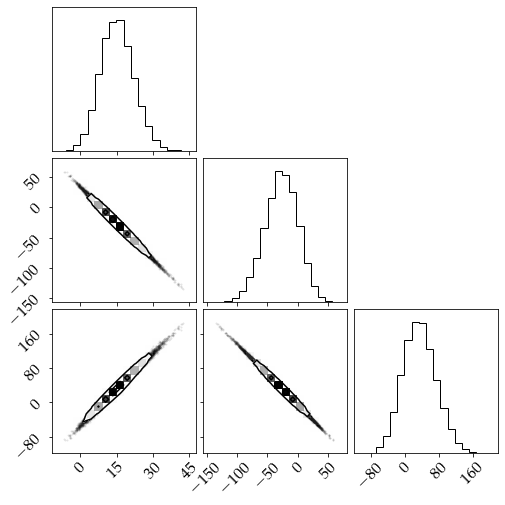

In [108]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.ionization.step-wise.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
fig.savefig("./ionization.step-wise.corner.pdf", dpi=1200)

## Resulting cross-section samples

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[

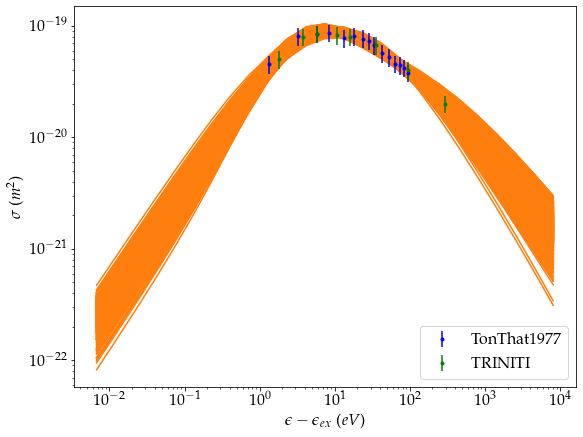

In [9]:
from models import *

flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.ionization.step-wise.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/3), 3])

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_step_ion[0]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = total_Ion_BED(sample[:3],Etest,E_step_ion[0])
    mask = models > 1.0e-25
    plt.plot(Etest[mask] - E_step_ion[0], models[mask], "C1", alpha=1)

for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0] - E_step_ion[0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
# plt.ylim([1e-21, 2e-19])
# plt.xlim([1e-1, 1e3])
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./ionization.step-wise.curve.pdf", dpi=1200)